In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/logistic_regression_dataset.csv")
X = df[['x1', 'x2']].values
y = df['target'].values.reshape(-1,1)
#Adding bias
X = np.hstack((np.ones((X.shape[0], 1)), X))

In [15]:
#Splitting the given data into 80% for train and 20% for test
np.random.seed(0)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [16]:
#Defining sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Computing the loss
def compute_loss(X, y, w):
    m = len(y)
    h = sigmoid(X @ w)

    #Making sure that h does not become exactly 0 or 1
    h = np.clip(h, 1e-15, 1 - 1e-15)
    loss = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return loss

In [19]:
def train(X, y, lr, epochs=500, tol=1e-4):
    m, n = X.shape
    w = np.zeros((n, 1))

    losses = []
    #Initializing the previous loss to infinity
    prev_loss = float('inf')

    for epoch in range(epochs):
        h = sigmoid(X @ w)

        #Finding gradient of cross entropy loss
        grad = (1/m) * (X.T @ (h - y))
        #Updating the weight
        w -= lr * grad

        #Computing the loss
        loss = compute_loss(X, y, w)
        losses.append(loss)

        if abs(prev_loss - loss) < tol:
            break

        prev_loss = loss

    return w, losses

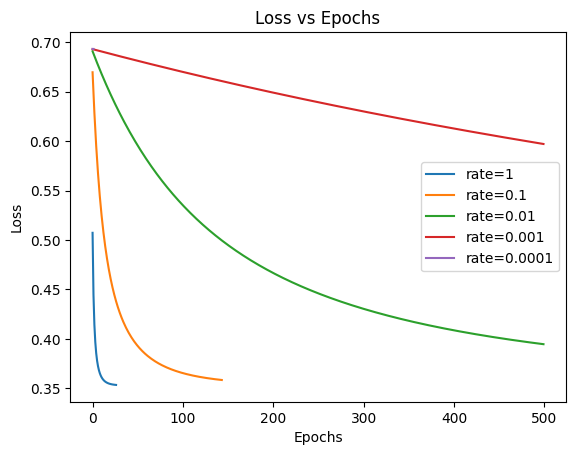

In [20]:
#(a)
#All 5 different learning rates
learning_rates = [1, 0.1, 0.01, 0.001, 0.0001]
all_losses = {}

plt.figure()

for lr in learning_rates:
    #Training on training data
    w, losses = train(X_train, y_train, lr)
    all_losses[lr] = losses
    plt.plot(losses, label=f"rate={lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

In [21]:
#Function to find the accuracy
def accuracy(X, y, w):
    preds = sigmoid(X @ w) >= 0.5
    return np.mean(preds == y)

In [23]:
#(b)
accuracies = {}

for lr in learning_rates:
    w, l = train(X_train, y_train, lr)

    train_accuracy = accuracy(X_train, y_train, w)
    test_accuracy = accuracy(X_test, y_test, w)

    accuracies[lr] = (train_accuracy, test_accuracy)
    print(f"LR={lr} | Train Accuracy={train_accuracy:.3f} | Test Accuracy={test_accuracy:.3f}")

LR=1 | Train Accuracy=0.856 | Test Accuracy=0.900
LR=0.1 | Train Accuracy=0.856 | Test Accuracy=0.905
LR=0.01 | Train Accuracy=0.853 | Test Accuracy=0.915
LR=0.001 | Train Accuracy=0.850 | Test Accuracy=0.920
LR=0.0001 | Train Accuracy=0.851 | Test Accuracy=0.920


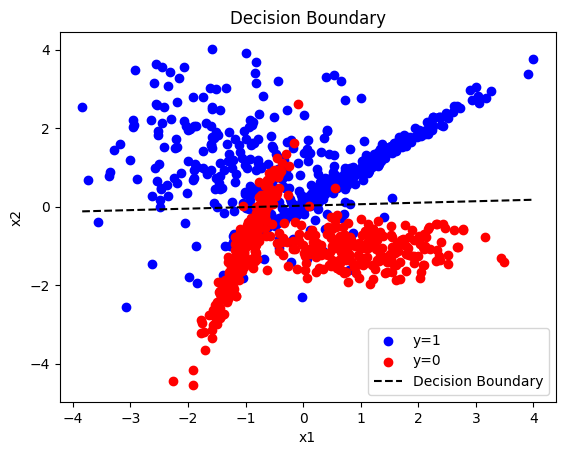

In [28]:
#(c)
best_lr = 0.001
w, l = train(X_train, y_train, best_lr)

plt.figure()

plt.scatter(X[y[:,0]==1, 1], X[y[:,0]==1, 2], color='blue', label='y=1')
plt.scatter(X[y[:,0]==0, 1], X[y[:,0]==0, 2], color='red',  label='y=0')

#Decision boundary
x_values = np.linspace(X[:,1].min(), X[:,1].max(), 100)
y_values = -(w[0] + w[1]*x_values) / w[2]

plt.plot(x_values, y_values, 'k--', label='Decision Boundary')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary")
plt.legend()
plt.show()

In [31]:
#(d)
def confusion_matrix(X, y, w):
    preds = (sigmoid(X @ w) >= 0.5).astype(int)

    TP = np.sum((preds == 1) & (y == 1))
    TN = np.sum((preds == 0) & (y == 0))
    FP = np.sum((preds == 1) & (y == 0))
    FN = np.sum((preds == 0) & (y == 1))

    return np.array([[TN, FP],
                     [FN, TP]])

matrix = confusion_matrix(X_test, y_test, w)
print("Confusion Matrix : \n", matrix)

Confusion Matrix : 
 [[88  0]
 [16 96]]
